In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

In [2]:
def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.

    Input
      ax: a matplotlib axis, e.g., as output from plt.gca().
    """

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call half the max range the plot radius.
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

Enter the filenames for control inputs and observations

In [3]:
# Load observations
observations = pd.read_csv(f'../data/trajectories/dynamic/observations_adiabatic_global_202.csv')
len(observations)
observations = observations.iloc[:, :10]
rest_positions = np.array([0.10056, -0.10541, 0.10350, 0.09808, -0.20127, 0.10645, 0.09242, -0.31915, 0.09713])
observations.iloc[:, 1:] = observations.iloc[:, 1:] - rest_positions

# Load the control inputs
control_file = '../data/trajectories/dynamic/control_inputs_adiabatic_global_202.csv'
control_inputs = pd.read_csv(control_file)

Plot settled points for each control input group

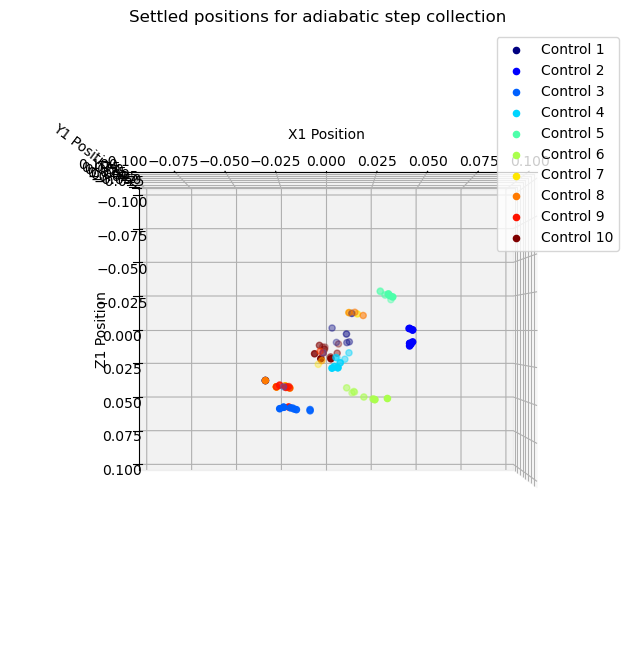

In [4]:
# Extract final settled positions for each trajectory
final_positions = observations.groupby("ID").last()[['x1', 'y1', 'z1']].reset_index()

# Merge observations with control inputs
merged_data = final_positions.merge(control_inputs, on="ID", how="left")

# Drop rows where there was no matching control input
merged_data = merged_data.dropna(subset=["u1", "u2", "u3", "u4", "u5", "u6"])

# Identify unique control input groups
control_columns = ["u1", "u2", "u3", "u4", "u5", "u6"]
merged_data["control_group"] = merged_data[control_columns].apply(tuple, axis=1)
# print(merged_data["u2"])

# Get unique control groups and assign colors
unique_controls = merged_data["control_group"].unique()
#print(unique_controls.size)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_controls)))
color_map = dict(zip(unique_controls, colors))

# Plot the 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


ct = 1
for control_group in unique_controls:
    subset = merged_data[merged_data["control_group"] == control_group]
    ax.scatter(subset["x1"], subset["y1"], subset["z1"], label=f"Control {ct}", color=color_map[control_group])
    # print(f'Control input {ct}: {control_group}')
    ct += 1


ax.set_xlabel("X1 Position")
ax.set_ylabel("Y1 Position")
ax.set_zlabel("Z1 Position")
ax.set_xlim([-0.1, 0.1])
ax.set_zlim([-0.1, 0.1])
ax.set_title("Settled positions for adiabatic step collection")
ax.legend()
ax.view_init(elev=180, azim=-90)
set_axes_equal(ax)

plt.show()

Generate hysteresis statistics

In [5]:
# For each control group, calculate the mean reference position
group_means = merged_data.groupby("control_group")[["x1", "y1", "z1"]].mean().reset_index()

# Merge back into merged_data to align each trajectory with its group's mean
merged_with_means = merged_data.merge(group_means, on="control_group", suffixes=("", "_mean"))

# Compute absolute errors
merged_with_means["x1_error"] = (merged_with_means["x1"] - merged_with_means["x1_mean"]).abs()
merged_with_means["y1_error"] = (merged_with_means["y1"] - merged_with_means["y1_mean"]).abs()
merged_with_means["z1_error"] = (merged_with_means["z1"] - merged_with_means["z1_mean"]).abs()

# Compute mean absolute error per control group and per dimension
mae_per_group = (
    merged_with_means.groupby("control_group")[["x1_error", "y1_error", "z1_error"]]
    .mean()
    .reset_index()
)

# Map control groups to Control 1, Control 2, ...
control_labels = {cg: f"Control {i+1}" for i, cg in enumerate(mae_per_group["control_group"])}
mae_per_group["control_label"] = mae_per_group["control_group"].map(control_labels)

print("Mean absolute error per control group per dimension (m):")
print(mae_per_group[["control_label", "x1_error", "y1_error", "z1_error"]])

# 1. Average error across each dimension (over all control groups)
avg_error_per_dimension = mae_per_group[["x1_error", "y1_error", "z1_error"]].mean()
print("\nAverage error across each dimension (all groups combined, mm):")
print(f'{avg_error_per_dimension*1000}')

print("\nAverage error across all dimensions and groups: (e)")
print(f'{avg_error_per_dimension.mean()*1000:.2f} mm')

print("\nMaximum norm displacement (d)")
max_disp = np.array([np.max(group_means["x1"]), np.max(group_means["y1"]), np.max(group_means["z1"])])
euc_disp_max = np.linalg.norm(max_disp)
print(f'{euc_disp_max*1000:.2f} mm')

print(f"\nPercentage Hysteresis ((e/d)*100%): {((avg_error_per_dimension.mean()/euc_disp_max)*100):.2f} %")


Mean absolute error per control group per dimension (m):
  control_label  x1_error  y1_error  z1_error
0     Control 1  0.004283  0.005535  0.002632
1     Control 2  0.013431  0.007226  0.015937
2     Control 3  0.003663  0.005424  0.004713
3     Control 4  0.006249  0.006619  0.002738
4     Control 5  0.003354  0.000433  0.003457
5     Control 6  0.001971  0.000470  0.003091
6     Control 7  0.013186  0.007696  0.011042
7     Control 8  0.013503  0.007748  0.016176
8     Control 9  0.001765  0.001274  0.001235
9    Control 10  0.008234  0.005929  0.005392

Average error across each dimension (all groups combined, mm):
x1_error    6.963863
y1_error    4.835289
z1_error    6.641310
dtype: float64

Average error across all dimensions and groups: (e)
6.15 mm

Maximum norm displacement (d)
74.77 mm

Percentage Hysteresis ((e/d)*100%): 8.22 %
